In [1]:
from tabpfn_project.helper.utils import load_pickle
from tabpfn_project.paths import RESULTS_DIR

tabpfn_results_dir = RESULTS_DIR / "TabPFN"
tabpfn_log_results = load_pickle(tabpfn_results_dir / "tabpfn_results_exp_instances_samples_grid.pkl")


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_ml_heatmap(results_data, visual_config, plot_scenario=None, plot_metric=None, plot_title=None, mark_best=False):
    """
    Generates a grid of heatmaps. Metrics follow fixed order.
    Tick marks are removed from axes and colorbars for a clean academic look.
    """
    # 1. Identify all available entities for filtering
    all_models = list(results_data.keys())
    all_scenarios = []
    all_metrics_found = []
    
    for model_runs in results_data.values():
        if model_runs:
            all_scenarios.extend([run['scenario'] for run in model_runs])
            all_metrics_found.extend(list(model_runs[0]['instance_summary'].keys()))
    
    all_scenarios = sorted(list(set(all_scenarios)))
    all_metrics_found = set(all_metrics_found)

    FIXED_METRIC_ORDER = ["NLLH", "CRPS", "Wasserstein", "KS"]
    
    if plot_metric is not None:
        requested_metrics = [plot_metric] if isinstance(plot_metric, str) else plot_metric
        metrics = sorted(requested_metrics, key=lambda x: FIXED_METRIC_ORDER.index(x) if x in FIXED_METRIC_ORDER else 99)
    else:
        metrics = [m for m in FIXED_METRIC_ORDER if m in all_metrics_found]

    if plot_scenario is not None:
        scenarios = [plot_scenario] if isinstance(plot_scenario, str) else plot_scenario
    else:
        scenarios = all_scenarios

    row_combinations = [(m, s) for m in all_models for s in scenarios if s in all_scenarios]
    num_rows = len(row_combinations)
    num_cols = len(metrics)
    
    fig, axes = plt.subplots(num_rows, num_cols, 
                             figsize=(8 * num_cols, 6 * num_rows), 
                             squeeze=False)

    for row_idx, (model_name, scenario) in enumerate(row_combinations):
        for col_idx, metric in enumerate(metrics):
            ax = axes[row_idx][col_idx]
            
            # --- AGGREGATION LOGIC (UNTOUCHED FLOW) ---
            runs = results_data[model_name]
            records = []
            for run in runs:
                if run['scenario'] == scenario:
                    values = run['instance_summary'].get(metric)
                    if values is None: continue
                    run_score = values.numpy().mean() if hasattr(values, 'numpy') else np.mean(values)
                    
                    # --- NEW: Check for full-dataset runs and calculate effective context_size ---
                    ctx_size = run['context_size']
                    is_full_dataset = False
                    
                    if ctx_size is None:
                        ctx_size = int(run['train_size'][0] / run['num_samples_per_instance'])
                        is_full_dataset = True
                    # ------------------------------------------------------------------------------
                    
                    records.append({
                        'context_size': ctx_size,
                        'num_samples_per_instance': run['num_samples_per_instance'],
                        'fold': run['fold'],
                        # Fix: Replace None with -1 so Pandas groupby doesn't silently drop full-dataset rows
                        'seed_ctx': run.get('seed_context_size', -1) if run.get('seed_context_size') is not None else -1,
                        'seed_samp': run['seed_samples_per_instance'],
                        'score': run_score,
                        'is_full': is_full_dataset  # Keep track of generated entries to normalize later
                    })
            
            if not records:
                ax.text(0.5, 0.5, "No Data", ha='center', va='center')
                continue
                
            # --- NEW: Normalize CV Fold Discrepancies for Maximum Instances (x and x+1) ---
            full_runs = [r for r in records if r['is_full']]
            if full_runs:
                max_ctx_map = {}
                # Find maximum instances computed for each subset of `num_samples_per_instance`
                for r in full_runs:
                    ns = r['num_samples_per_instance']
                    if ns not in max_ctx_map or r['context_size'] > max_ctx_map[ns]:
                        max_ctx_map[ns] = r['context_size']
                
                # Assign to x+1 uniformly
                for r in records:
                    if r['is_full']:
                        r['context_size'] = max_ctx_map[r['num_samples_per_instance']]
            # ------------------------------------------------------------------------------

            df = pd.DataFrame(records)
            df_step2 = df.groupby(['fold', 'seed_ctx', 'context_size', 'num_samples_per_instance'])['score'].mean().reset_index()
            df_step3 = df_step2.groupby(['fold', 'context_size', 'num_samples_per_instance'])['score'].mean().reset_index()
            final_df = df_step3.groupby(['context_size', 'num_samples_per_instance'])['score'].mean().reset_index()
            
            pivot_table = final_df.pivot(index='context_size', columns='num_samples_per_instance', values='score')
            pivot_table = pivot_table.sort_index(ascending=True).sort_index(axis=1, ascending=True)
            # ------------------------------------

            cmap = visual_config.get('cmap', 'viridis')
            annot = visual_config.get('annot', True)
            fmt = visual_config.get('fmt', '.4f')
            
            # --- NEW: Add mask=pivot_table.isnull() to handle sparsity without breaking annotations ---
            # --- NEW: Add mask=pivot_table.isnull() to handle sparsity without breaking annotations ---
            sns.heatmap(
                pivot_table, annot=annot, fmt=fmt, cmap=cmap, 
                cbar_kws={'label': metric}, linewidths=.5, ax=ax,
                mask=pivot_table.isnull()
            )
            
            # --- NEW FUNCTIONALITY: HIGHLIGHT BEST SCORES ---
            if mark_best and not pivot_table.empty:
                global_min = pivot_table.min().min()
                
                for i, (idx, row) in enumerate(pivot_table.iterrows()):
                    if row.isnull().all():
                        continue
                    
                    local_min = row.min()
                    best_col = row.idxmin()
                    j = pivot_table.columns.get_loc(best_col)
                    
                    # CHANGED: Offset to the true top-right corner.
                    # Because ax.invert_yaxis() is called later, y=i+1 is the visual top of the cell.
                    x_pos = j + 0.85
                    y_pos = i + 0.85 
                    
                    if local_min == global_min:
                        ax.scatter(x_pos, y_pos, color='gold', marker='*', s=150, 
                                   edgecolor='black', linewidth=0.5, zorder=5)
                    else:
                        ax.scatter(x_pos, y_pos, color='silver', marker='*', s=70, 
                                   edgecolor='black', linewidth=0.5, zorder=5)
            # ------------------------------------------------
            
            # --- NEW: REMOVE TICK MARKS ---
            
            # --- NEW: REMOVE TICK MARKS ---
            # Remove tick marks from X and Y axes
            ax.tick_params(axis='both', which='both', length=0)
            
            # Remove tick marks from the colorbar (accessing via the heatmap collection)
            cbar = ax.collections[0].colorbar
            if cbar:
                cbar.ax.tick_params(axis='both', which='both', length=0)
            # ------------------------------

            ax.invert_yaxis() 
            
            if row_idx == 0:
                ax.set_title(f"Metric: {metric}", fontsize=14, fontweight='bold')
            
            # CHANGED: Match reference.txt multiline y-axis layout and styling
            if col_idx == 0:
                ax.set_ylabel(f"{scenario}\n# Instances", fontsize=12, fontweight='bold')
            else:
                ax.set_ylabel("# Instances", fontsize=12, fontweight='bold')
                
            ax.set_xlabel("# Samples per Instance")

    if plot_title:
        fig.suptitle(plot_title, fontsize=18, fontweight='bold')
        # ADOPTED FROM reference.txt: Adjusted top padding to 0.96
        plt.tight_layout(rect=[0, 0, 1, 0.96])
    else:
        plt.tight_layout()
        
    return fig

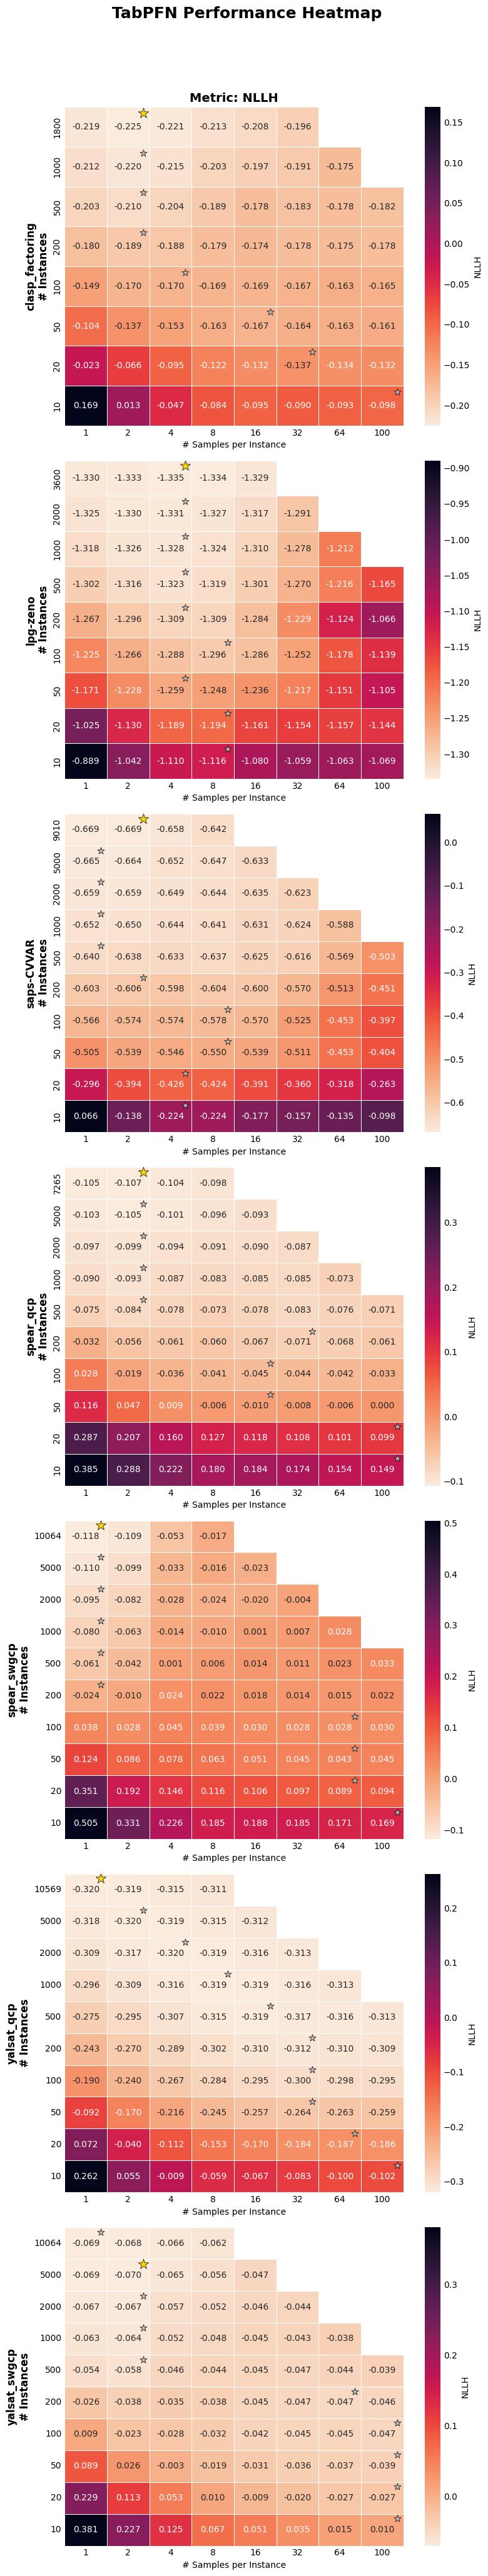

In [3]:
results_dict = {
    "TabPFN": tabpfn_log_results
}

scenarios = [
    "clasp_factoring",
    "saps-CVVAR",
    "spear_qcp",
    "yalsat_qcp",
    "spear_swgcp",
    "yalsat_swgcp",
    "lpg-zeno"
]

metrics = [
    "NLLH",
    "CRPS",
    "Wasserstein",
    "KS"
]

v_cfg = {
        "cmap": "rocket_r", 
        "annot": True, 
        "fmt": ".3f"
    }

fig = plot_ml_heatmap(
        results_data=results_dict,
        visual_config=v_cfg,
        plot_scenario=None,
        plot_metric="NLLH",
        mark_best=True,
        plot_title="TabPFN Performance Heatmap"
    )
plt.show()

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def plot_heatmap_scatter(results_data, visual_config, n_instances=None, n_samples_per_instance=None, 
                         log_x=False, log_y=False, zoom_on_model=None, plot_title=None, 
                         mark_best=False, plot_scenario=None, plot_metric=None):
    """
    Generates styled line/scatter plots with variance shading derived from heatmap data.
    Exactly one of `n_instances` or `n_samples_per_instance` must be provided.
    """
    # 1. Validation
    if (n_instances is None) == (n_samples_per_instance is None):
        raise ValueError("Exactly one of 'n_instances' or 'n_samples_per_instance' must be provided.")
        
    if set(results_data.keys()) != set(visual_config.keys()):
        raise KeyError("The keys in results_data and visual_config must match exactly.")
    
    if zoom_on_model is not None and zoom_on_model not in results_data.keys():
        raise ValueError(f"zoom_on_model '{zoom_on_model}' not found in results_data keys.")

    # 2. Flatten and Pre-process Data
    all_records = []
    all_scenarios = []
    all_metrics_found = []
    
    for model_runs in results_data.values():
        if model_runs:
            all_scenarios.extend([run['scenario'] for run in model_runs])
            all_metrics_found.extend(list(model_runs[0]['instance_summary'].keys()))
    
    all_scenarios = sorted(list(set(all_scenarios)))
    all_metrics_found = set(all_metrics_found)

    FIXED_METRIC_ORDER = ["NLLH", "CRPS", "Wasserstein", "KS"]
    if plot_metric is not None:
        requested_metrics = [plot_metric] if isinstance(plot_metric, str) else plot_metric
        metrics = sorted(requested_metrics, key=lambda x: FIXED_METRIC_ORDER.index(x) if x in FIXED_METRIC_ORDER else 99)
    else:
        metrics = [m for m in FIXED_METRIC_ORDER if m in all_metrics_found]

    scenarios = [plot_scenario] if isinstance(plot_scenario, str) else plot_scenario
    scenarios = scenarios if scenarios is not None else all_scenarios

    for model_name, runs in results_data.items():
        for scenario in scenarios:
            scen_runs = [r for r in runs if r['scenario'] == scenario]
            if not scen_runs: continue
            
            scen_records = []
            for run in scen_runs:
                ctx_size = run['context_size']
                is_full_dataset = False
                if ctx_size is None:
                    ctx_size = int(run['train_size'][0] / run['num_samples_per_instance'])
                    is_full_dataset = True
                    
                for metric in metrics:
                    values = run['instance_summary'].get(metric)
                    if values is None: continue
                    run_score = values.numpy().mean() if hasattr(values, 'numpy') else np.mean(values)
                    
                    scen_records.append({
                        "model": model_name,
                        "scenario": scenario,
                        "metric": metric,
                        "context_size": ctx_size,
                        "num_samples_per_instance": run['num_samples_per_instance'],
                        "fold": run['fold'],
                        "seed_ctx": run.get('seed_context_size', -1) if run.get('seed_context_size') is not None else -1,
                        "score": run_score,
                        "is_full": is_full_dataset
                    })
            
            # Normalize CV Fold Discrepancies
            full_runs = [r for r in scen_records if r['is_full']]
            if full_runs:
                max_ctx_map = {}
                for r in full_runs:
                    ns = r['num_samples_per_instance']
                    if ns not in max_ctx_map or r['context_size'] > max_ctx_map[ns]:
                        max_ctx_map[ns] = r['context_size']
                for r in scen_records:
                    if r['is_full']:
                        r['context_size'] = max_ctx_map[r['num_samples_per_instance']]
                        
            all_records.extend(scen_records)

    df = pd.DataFrame(all_records)
    if df.empty:
        raise ValueError("No data found to plot.")

    # Apply axis filtering based on user input
    # Apply axis filtering based on user input
    if n_instances is not None:
        # --- CHANGED: Fallback to scenario max if requested n_instances is too large ---
        filtered_dfs = []
        for scen in df['scenario'].unique():
            scen_df = df[df['scenario'] == scen]
            # Clamp the requested instances to the maximum available for this scenario
            target_instances = min(n_instances, scen_df['context_size'].max())
            filtered_dfs.append(scen_df[scen_df['context_size'] == target_instances])
            
        df = pd.concat(filtered_dfs) if filtered_dfs else pd.DataFrame()
        # ------------------------------------------------------------------------------
        x_col = 'num_samples_per_instance'
        x_label = "# Samples per Instance"
    else:
        df = df[df['num_samples_per_instance'] == n_samples_per_instance]
        x_col = 'context_size'
        x_label = "Context Size"

    if df.empty:
        raise ValueError("No data found after filtering for the specified instances/samples.")

    # 3. Plotting Setup
    fig, axes = plt.subplots(len(scenarios), len(metrics), 
                             figsize=(6 * len(metrics), 5 * len(scenarios)), 
                             squeeze=False)

    for row_idx, scenario in enumerate(scenarios):
        # --- NEW: Calculate x-axis variables LOCALLY per scenario ---
        scenario_df = df[df['scenario'] == scenario]
        if scenario_df.empty:
            continue
            
        scenario_max_x = scenario_df[x_col].max()
        scenario_x_sizes = sorted(scenario_df[x_col].unique())
        # ------------------------------------------------------------
        
        for col_idx, metric in enumerate(metrics):
            ax = axes[row_idx][col_idx]
            
            zoom_bounds = {"min": float('inf'), "max": float('-inf')}
            abs_best_val = float('inf')
            abs_best_model = None
            abs_best_coords = (None, None)
            line_objs = {}
            added_early_term_legend = False 
            
            for model_name, (color, hatch) in visual_config.items():
                subset = scenario_df[(scenario_df['model'] == model_name) & 
                                     (scenario_df['metric'] == metric)]
                
                if subset.empty:
                    continue

                df_step2 = subset.groupby(['fold', 'seed_ctx', x_col])['score'].mean().reset_index()
                df_step3 = df_step2.groupby(['fold', x_col])['score'].mean().reset_index()
                
                final_stats = df_step3.groupby(x_col)['score'].agg(['mean', 'std']).reset_index()
                final_stats = final_stats.sort_values(x_col)
                
                x = final_stats[x_col]
                y_mean = final_stats['mean']
                y_std = final_stats['std'].fillna(0)
                
                line, = ax.plot(x, y_mean, label=model_name, color=color, marker='o', markersize=4)
                line_objs[model_name] = line
                
                lower_bound = y_mean - y_std
                upper_bound = y_mean + y_std
                
                if log_y and metric != 'NLLH':
                    lower_bound = np.maximum(lower_bound, y_mean * 0.1)
                
                ax.fill_between(x, lower_bound, upper_bound, 
                                color=color, alpha=0.2, hatch=hatch, edgecolor='none')
                
                # --- EARLY TERMINATION MARKER ---
                current_max_x = x.max()
                if current_max_x < scenario_max_x:
                    last_x = final_stats[x_col].iloc[-1]
                    last_y = final_stats['mean'].iloc[-1]
                    
                    if log_x:
                        x_offset = last_x * 1.15  
                    else:
                        # Use local scenario_x_sizes[0] instead of global
                        x_range = scenario_max_x - scenario_x_sizes[0]
                        x_offset = last_x + (x_range * 0.04) 
                        
                    label = 'Timeout' if not added_early_term_legend else '_nolegend_'
                    ax.scatter(x_offset, last_y, color=color, marker='x', s=60, 
                               linewidth=1.5, zorder=6, label=label)
                    added_early_term_legend = True

                current_min = y_mean.min()
                if current_min < abs_best_val:
                    abs_best_val = current_min
                    abs_best_model = model_name
                    best_x = x[y_mean.idxmin()]
                    abs_best_coords = (best_x, current_min)

                if zoom_on_model == model_name:
                    lower_bound = (y_mean - y_std).min()
                    upper_bound = (y_mean + y_std).max()
                    zoom_bounds["min"] = min(zoom_bounds["min"], lower_bound)
                    zoom_bounds["max"] = max(zoom_bounds["max"], upper_bound)

            if mark_best and abs_best_model is not None:
                bx, by = abs_best_coords
                ax.scatter(bx, by, color='gold', marker='*', s=150, 
                           edgecolor='black', linewidth=0.5, zorder=5, label='_nolegend_')
                original_label = line_objs[abs_best_model].get_label()
                line_objs[abs_best_model].set_label(f"{original_label} <-- Best")

            if log_x:
                ax.set_xscale('log')
                ax.set_xticks(scenario_x_sizes) # Apply local ticks
                ax.xaxis.set_major_formatter(ScalarFormatter())
                plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
            
            if log_y and metric != 'NLLH':
                ax.set_yscale('log')

            if zoom_on_model is not None:
                margin = (zoom_bounds["max"] - zoom_bounds["min"]) * 0.05
                low, high = zoom_bounds["min"] - margin, zoom_bounds["max"] + margin
                if log_y and metric != 'NLLH' and low <= 0:
                    if zoom_bounds["min"] > 0:
                        low = zoom_bounds["min"] * 0.9
                    else:
                        low = 1e-9
                ax.set_ylim(low, high)

            if zoom_on_model is not None:
                current_ylim_max = ax.get_ylim()[1]
                for model_name, line in line_objs.items():
                    subset = scenario_df[(scenario_df['model'] == model_name) & 
                                         (scenario_df['metric'] == metric)]
                    if subset.empty: continue
                    
                    df_step2 = subset.groupby(['fold', 'seed_ctx', x_col])['score'].mean().reset_index()
                    df_step3 = df_step2.groupby(['fold', x_col])['score'].mean().reset_index()
                    stats = df_step3.groupby(x_col)['score'].agg(['mean', 'std'])
                    
                    if (stats['mean'] - stats['std'].fillna(0)).min() > current_ylim_max:
                        current_label = line.get_label()
                        if " <-- Best" not in current_label:
                            line.set_label(f"{current_label} (≫)") 

            if row_idx == 0:
                ax.set_title(f"Metric: {metric}", fontsize=14, fontweight='bold')
            
            if col_idx == 0:
                ax.set_ylabel(f"{scenario}\n{metric}", fontsize=12, fontweight='bold')
            else:
                ax.set_ylabel(metric, fontsize=12, fontweight='bold')
            
            ax.set_xlabel(x_label)
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.legend(loc='upper right', fontsize=9)

    if plot_title:
        fig.suptitle(plot_title, fontsize=18, fontweight='bold')
        plt.tight_layout(rect=[0, 0, 1, 0.96]) 
    else:
        plt.tight_layout()
        
    plt.close(fig) 
    return fig

In [20]:
scenarios = [
    "clasp_factoring",
    "saps-CVVAR",
    "spear_qcp",
    "yalsat_qcp",
    "spear_swgcp",
    "yalsat_swgcp",
    "lpg-zeno"
]

metrics = [
    "NLLH",
    "CRPS",
    "Wasserstein",
    "KS"
]

results_dict = {
    # --- The Star Model ---
    "TabPFN": tabpfn_log_results,
    
}

visual_cfg = {
    # --- The Star Model ---
    "TabPFN": ("#2CA02C", "xx"),           # Green
    
}

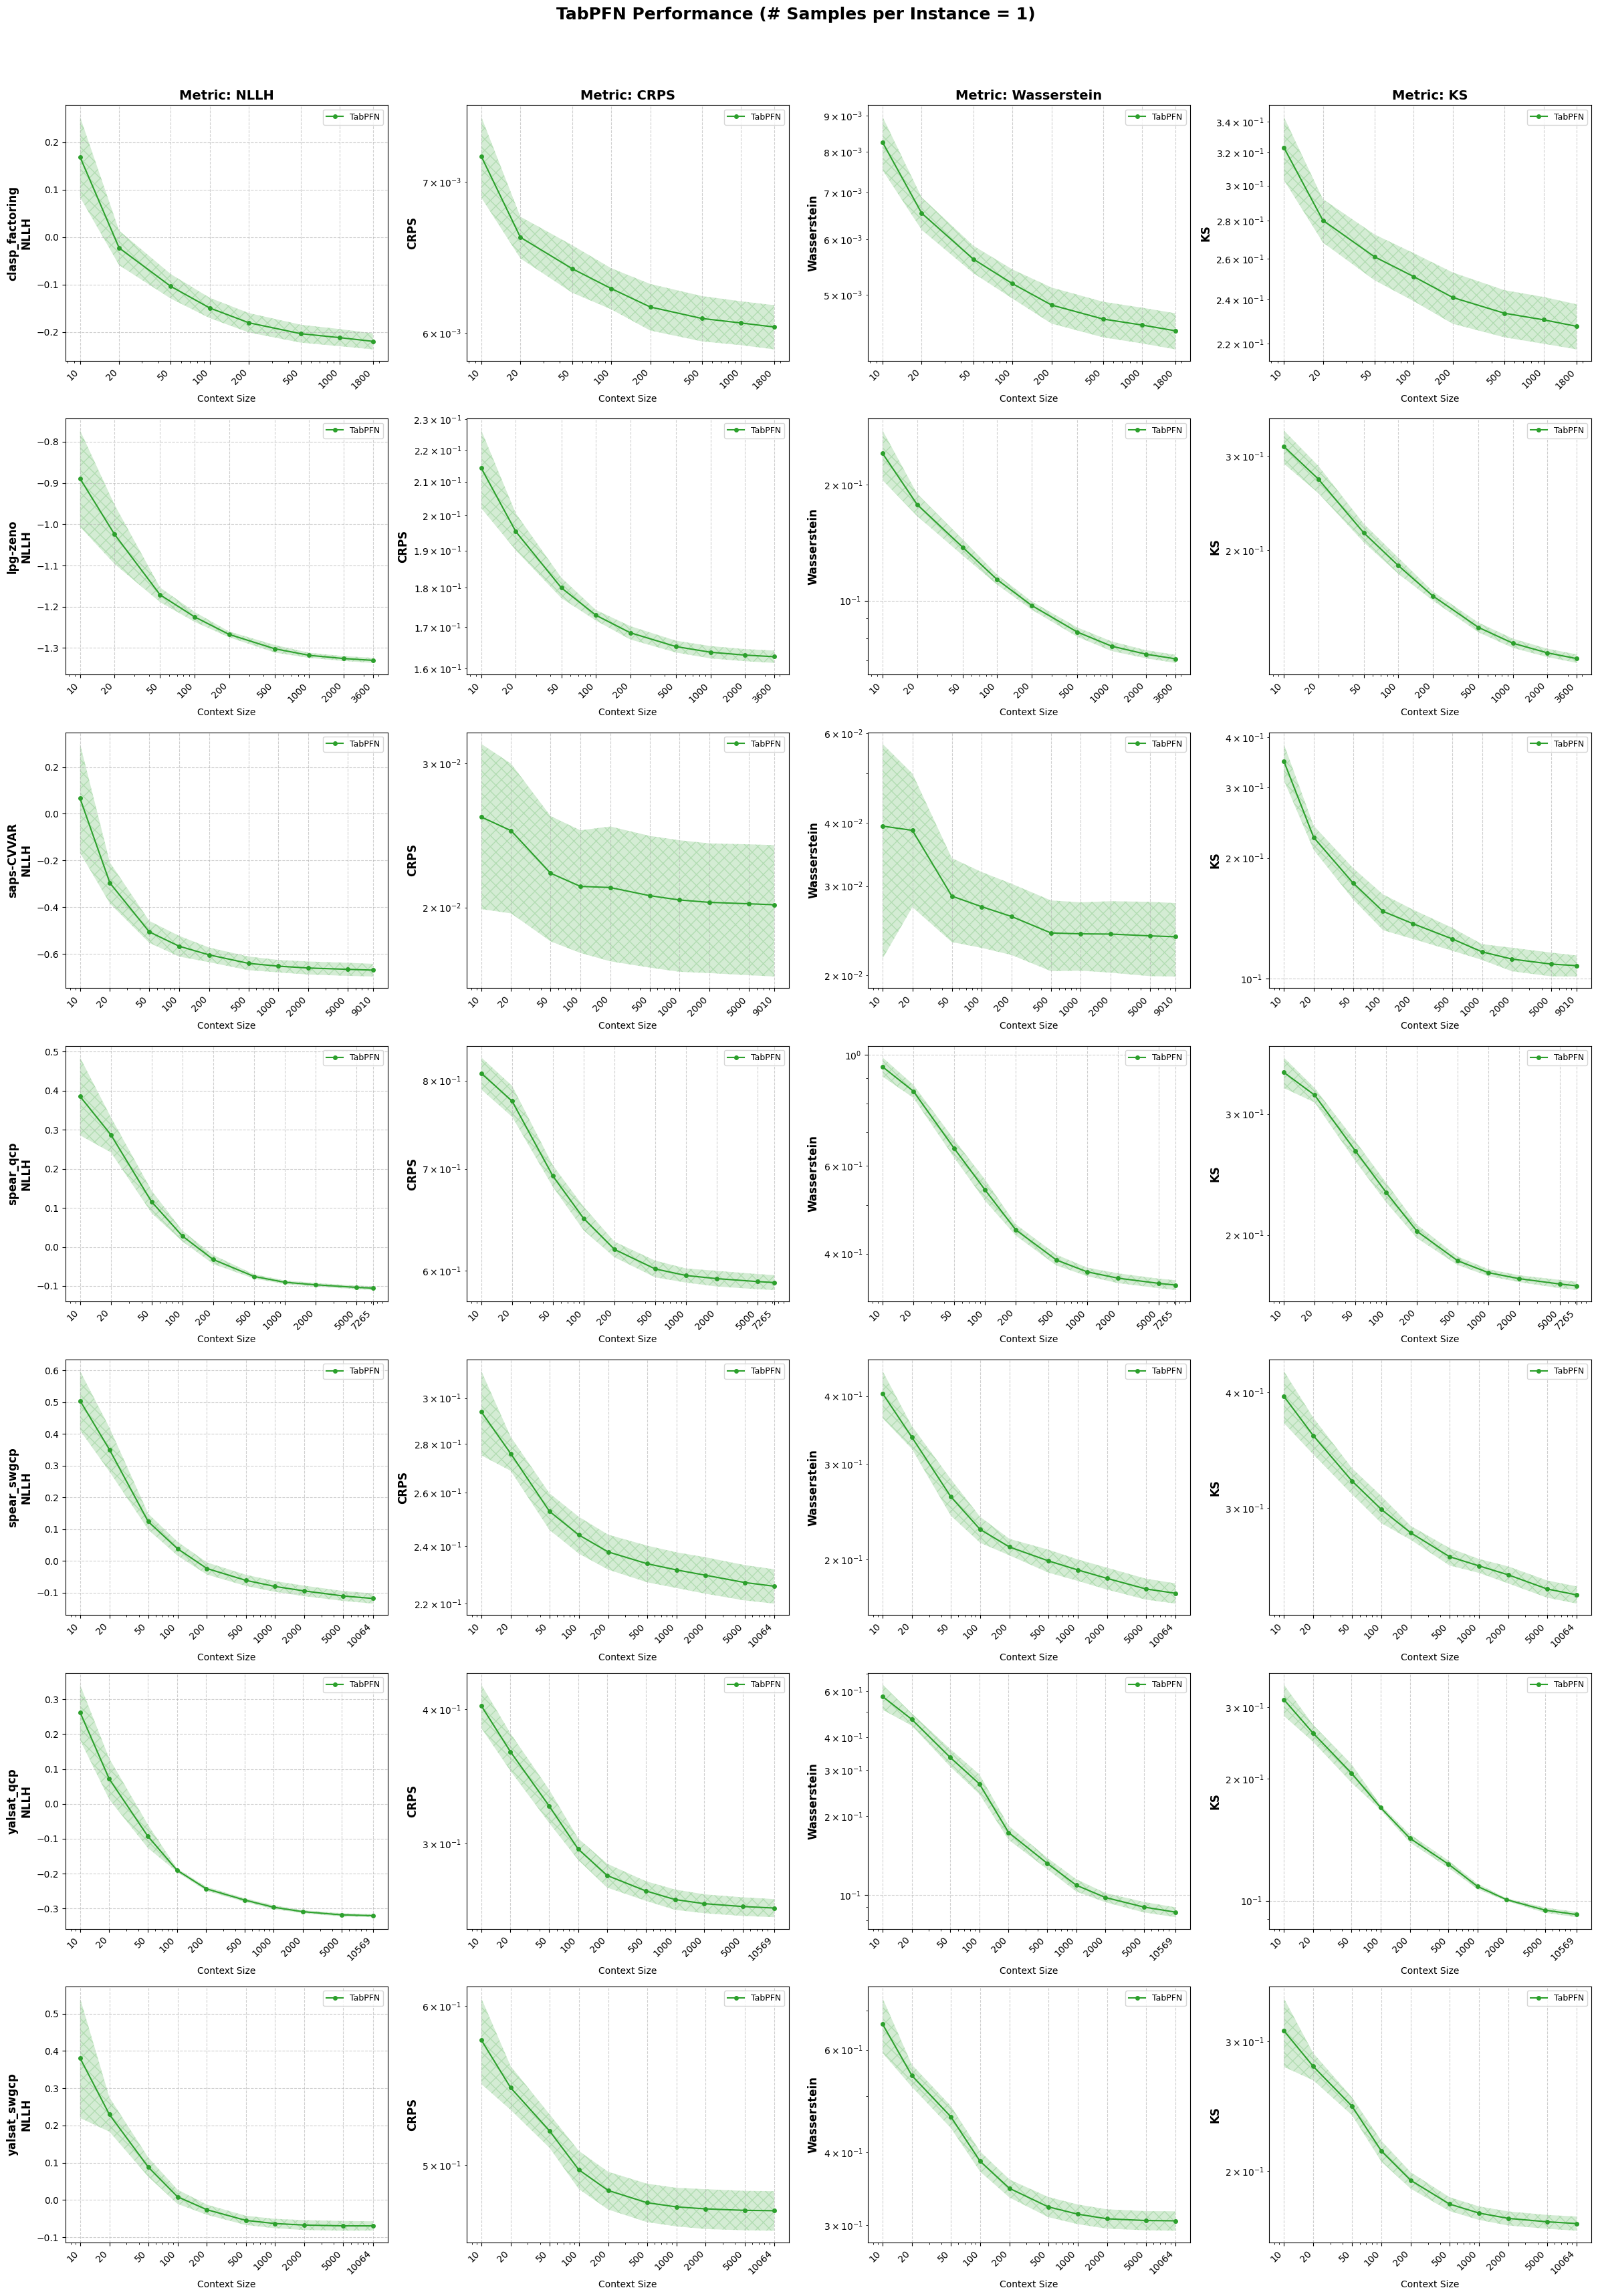

In [21]:
n_samples_per_instance=1
plot_heatmap_scatter(results_dict, visual_cfg, n_samples_per_instance=n_samples_per_instance, log_x=True, log_y=True, plot_scenario=None, plot_title=f"TabPFN Performance (# Samples per Instance = {n_samples_per_instance}) ")

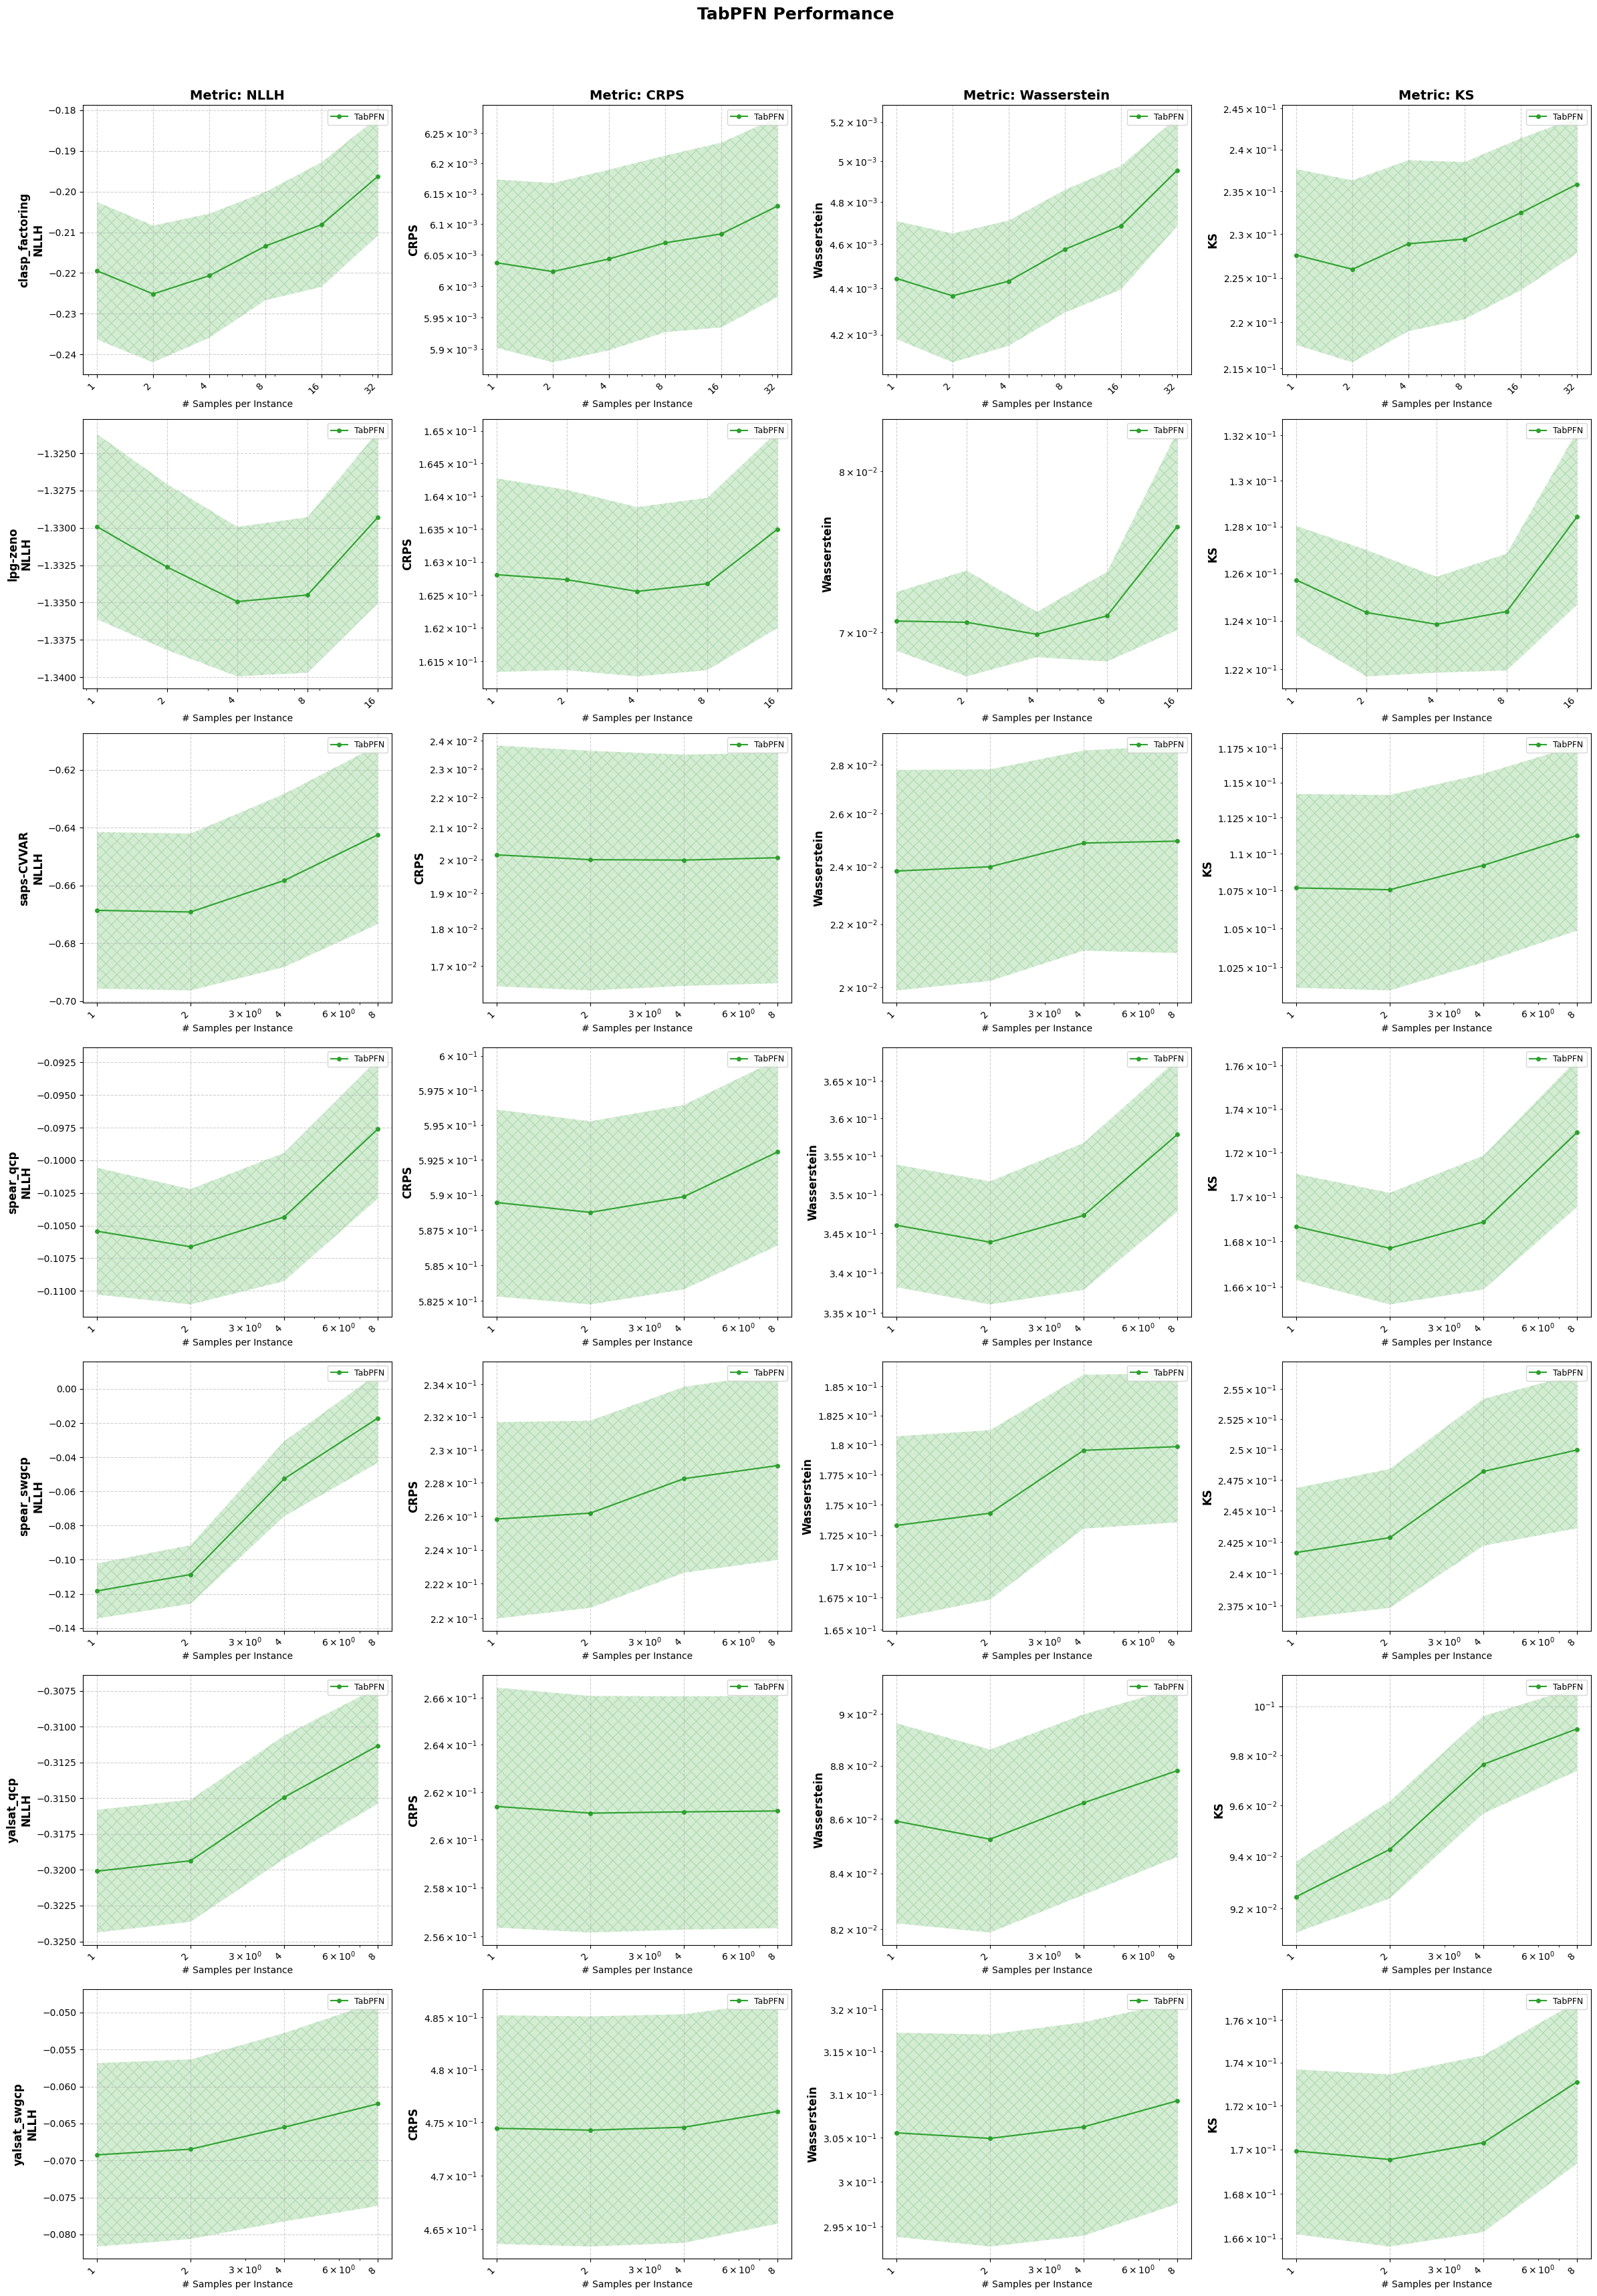

In [23]:
n_instances=20000
plot_heatmap_scatter(results_dict, visual_cfg, n_instances=n_instances, log_x=True, log_y=True, plot_scenario=None, plot_title=f"TabPFN Performance ")